In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=af0405fb322a487974c294b5d3de0cc5624e702b0e46e781ef42ed824f17e4bc
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
!pip install tensorflow

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import ta
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import itertools
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("Warning: TensorFlow/Keras not found. LSTM/CNN models will fail.")
warnings.filterwarnings('ignore')

#Load ALL datasets (CSV format, using ticker symbols)
try:
    #Banking
    df_axbk = pd.read_csv('AXBK Historical Data.csv') # Axis
    df_icbk = pd.read_csv('ICBK Historical Data.csv') # ICICI
    df_yesb = pd.read_csv('YESB Historical Data.csv') # Yes
    df_idbi = pd.read_csv('IDBI Historical Data.csv') # IDBI
    df_hdbk = pd.read_csv('HDBK Historical Data.csv') # HDFC
    df_kotak = pd.read_csv('KOTAK Historical Data.csv') # Kotak
    df_sbi = pd.read_csv('SBI Historical Data.csv')   # SBI
    df_bob = pd.read_csv('BOB Historical Data.csv')   # BOB
    df_cnbk = pd.read_csv('CNBK Historical Data.csv') # Canara
    df_pnb = pd.read_csv('PNB Historical Data.csv')   # PNB
    #Pharma / Healthcare
    df_aplh = pd.read_csv('APLH Historical Data.csv') # Apollo Hospitals
    df_cipl = pd.read_csv('CIPL Historical Data.csv') # Cipla
    df_divi = pd.read_csv('DIVI Historical Data.csv') # Divi's Labs
    df_fore = pd.read_csv('FOHE Historical Data.csv') # Fortis
    df_sun = pd.read_csv('SUN Historical Data.csv')   # Sun Pharma
    df_redy = pd.read_csv('DRREDDY Historical Data.csv') # Dr. Reddy's
    #FMCG
    df_brit = pd.read_csv('BRIT Historical Data.csv') # Britannia
    df_itc = pd.read_csv('ITC Historical Data.csv')
    df_mrco = pd.read_csv('MRCO Historical Data.csv') # Marico
    df_nest = pd.read_csv('NEST Historical Data.csv') # Nestle
    df_hll = pd.read_csv('HLL Historical Data.csv')   # HUL
    df_dabu = pd.read_csv('DABUR Historical Data.csv') # Dabur
    #Automotive
    df_teml = pd.read_csv('TEML Historical Data.csv') # Tata Motors
    df_mrti = pd.read_csv('MARUTI Historical Data.csv') # Maruti
    df_mahm = pd.read_csv('MM Historical Data.csv') # M&M
    df_baja = pd.read_csv('BAJAJAUTO Historical Data.csv') # Bajaj Auto
    df_hrom = pd.read_csv('HERO Historical Data.csv') # Hero MotoCorp
    df_asok = pd.read_csv('ASHOK Historical Data.csv') # Ashok Leyland
    #IT Services
    df_tcs = pd.read_csv('TCS Historical Data.csv')
    df_infy = pd.read_csv('INFY Historical Data.csv') # Infosys
    df_wipr = pd.read_csv('WIPR Historical Data.csv') # Wipro
    df_hclt = pd.read_csv('HCLI Historical Data.csv') # HCL Tech
    #Diversified / Energy
    df_adanient = pd.read_csv('ADANIENT Historical Data.csv') # Adani Ent.
    df_reli = pd.read_csv('RELI Historical Data.csv') # Reliance
    print("All CSV files loaded successfully.")
except FileNotFoundError as e:
    print(f"CRITICAL ERROR loading file: {e}. Ensure all CSV files are present.")
    raise SystemExit(f"Exiting due to missing file: {e}")
except pd.errors.EmptyDataError as e:
    print(f"CRITICAL ERROR: File {e} is empty.")
    raise SystemExit(f"Exiting due to empty file: {e}")
except Exception as e:
    print(f"An unexpected error occurred during file loading: {e}")
    raise SystemExit(f"Exiting due to file loading error: {e}")

#Organize into sectors
sectors = {
    "Banking": {
        "AXBK": df_axbk, "ICBK": df_icbk, "YESB": df_yesb, "IDBI": df_idbi,
        "HDBK": df_hdbk, "KOTAK": df_kotak, "SBI": df_sbi, "BOB": df_bob,
        "CNBK": df_cnbk, "PNB": df_pnb
    },
    "Pharma / Healthcare": {
        "APLH": df_aplh, "CIPL": df_cipl, "DIVI": df_divi, "FORE": df_fore,
        "SUN": df_sun, "REDY": df_redy
    },
    "FMCG": {
        "BRIT": df_brit, "ITC": df_itc, "MRCO": df_mrco, "NEST": df_nest,
        "HLL": df_hll, "DABU": df_dabu
    },
    "Automotive": {
        "TEML": df_teml, "MRTI": df_mrti, "MAHM": df_mahm,
        "BAJA": df_baja, "HROM": df_hrom, "ASOK": df_asok
    },
    "IT Services": {
        "TCS": df_tcs, "INFY": df_infy, "WIPR": df_wipr, "HCLT": df_hclt
    },
    "Diversified / Energy": {
        "ADANIENT": df_adanient, "RELI": df_reli
    }
}
print(f"Created {len(sectors)} sectors.")


All CSV files loaded successfully.
Created 6 sectors.


In [ ]:
#Pair Discovery Across All Sectors

import itertools
import pandas as pd
import numpy as np
from tqdm import tqdm
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm

all_candidate_pairs = []  # Store all pairs from all sectors

print("\nStarting Pair Discovery for ALL Sectors")
print("Testing all combinations for Cointegration (coint) and Stationarity (ADF)...")

#Main loop through each sector
for sector_name, stocks_in_sector in sectors.items():
    print(f"\nScanning Sector: {sector_name}")

    # Filter out empty or invalid DataFrames
    available_stocks = {
        name: df for name, df in stocks_in_sector.items()
        if isinstance(df, pd.DataFrame) and not df.empty and len(df) > 100
    }
    stock_symbols = list(available_stocks.keys())

    if len(stock_symbols) < 2:
        print(f"Skipping {sector_name}: Not enough valid stocks.")
        continue

    # Optional optimization: limit combinations for very large sectors
    max_stocks = min(len(stock_symbols), 50)
    stock_symbols = stock_symbols[:max_stocks]

    # Progress bar for this sector
    for stockA_sym, stockB_sym in tqdm(
        itertools.combinations(stock_symbols, 2),
        desc=f"Analyzing {sector_name}", leave=False
    ):
        df_A_raw = available_stocks[stockA_sym].copy()
        df_B_raw = available_stocks[stockB_sym].copy()

        try:
            #Standardize and prepare
            df_A = standardize_columns(df_A_raw)
            df_B = standardize_columns(df_B_raw)

            if 'date' not in df_A.columns or 'date' not in df_B.columns:
                continue
            if 'close' not in df_A.columns or 'close' not in df_B.columns:
                continue

            df_A['date'] = pd.to_datetime(df_A['date'], errors='coerce')
            df_B['date'] = pd.to_datetime(df_B['date'], errors='coerce')
            df_A = df_A.dropna(subset=['date']).set_index('date')
            df_B = df_B.dropna(subset=['date']).set_index('date')

            A_close = pd.to_numeric(df_A['close'].astype(str).str.replace(',', ''), errors='coerce')
            B_close = pd.to_numeric(df_B['close'].astype(str).str.replace(',', ''), errors='coerce')

            pair_data = pd.merge(
                A_close.rename(stockA_sym),
                B_close.rename(stockB_sym),
                left_index=True,
                right_index=True,
                how='inner'
            ).dropna()

            # Require at least 1 year of data
            if len(pair_data) < 252:
                continue

            #1. Cointegration Test
            coint_score, coint_pvalue, _ = coint(pair_data[stockA_sym], pair_data[stockB_sym])

            #2. OLS Regression and ADF Test on Spread
            X_ols = sm.add_constant(pair_data[stockB_sym])
            y_ols = pair_data[stockA_sym]
            model_ols = sm.OLS(y_ols, X_ols).fit()

            # Safer extraction of beta
            beta = model_ols.params.get(stockB_sym, model_ols.params.iloc[1])

            spread = pair_data[stockA_sym] - beta * pair_data[stockB_sym]
            spread = spread.dropna()

            # Skip if insufficient data for ADF
            if len(spread) < 50:
                continue

            adf_result = adfuller(spread)
            adf_pvalue = adf_result[1]

            #3. Save if both conditions met
            if coint_pvalue < 0.05 and adf_pvalue < 0.05:
                all_candidate_pairs.append({
                    "Sector": sector_name,
                    "Stock 1": stockA_sym,
                    "Stock 2": stockB_sym,
                    "Cointegration P-Value": coint_pvalue,
                    "ADF P-Value": adf_pvalue,
                    "Tested Points": len(pair_data)
                })

        except Exception:
            # Ignore problematic pairs silently
            continue

#Display Results
if all_candidate_pairs:
    results_df = pd.DataFrame(all_candidate_pairs)

    # Weighted combined score (cointegration weighted more)
    results_df['Combined P-Value'] = (
        0.6 * results_df['Cointegration P-Value'] +
        0.4 * results_df['ADF P-Value']
    )

    results_df = results_df.sort_values(by='Combined P-Value', ascending=True)

    print("\nTop 15 Promising Pair Candidates (All Sectors, p < 0.05)")
    print(results_df.head(15).to_string(formatters={
        'Cointegration P-Value': '{:.4f}'.format,
        'ADF P-Value': '{:.4f}'.format,
        'Combined P-Value': '{:.4f}'.format
    }))

    results_df.to_csv("pair_candidates_ALL_SECTORS.csv", index=False)
    print("\nNOTE: Review this list, then select your desired pair in the next cell.")

else:
    print("\nNo statistically significant (p < 0.05) pairs found across all sectors with > 252 data points.")



Starting Pair Discovery for ALL Sectors
Testing all combinations for Cointegration (coint) and Stationarity (ADF)...

Scanning Sector: Banking



Scanning Sector: Pharma / Healthcare



Scanning Sector: FMCG



Scanning Sector: Automotive



Scanning Sector: IT Services



Scanning Sector: Diversified / Energy



Top 15 Promising Pair Candidates (All Sectors, p < 0.05)
                 Sector Stock 1 Stock 2 Cointegration P-Value ADF P-Value  Tested Points Combined P-Value
4   Pharma / Healthcare    FORE     SUN                0.0001      0.0000           3919           0.0000
12           Automotive    MAHM    BAJA                0.0001      0.0000           3926           0.0001
5   Pharma / Healthcare    FORE    REDY                0.0003      0.0000           3919           0.0002
10                 FMCG     HLL    DABU                0.0004      0.0001           3920           0.0002
1               Banking    HDBK   KOTAK                0.0015      0.0003           3926           0.0010
2   Pharma / Healthcare    APLH    CIPL                0.0026      0.0005           3926           0.0018
13          IT Services    INFY    WIPR                0.0094      0.0019           3926           0.0064
11           Automotive    MRTI    ASOK                0.0096      0.0020           3920      

In [ ]:
# Helper function for standardization
def standardize_columns(df):
    df.columns = df.columns.str.strip().str.lower()
    rename_map = {'price': 'close'}
    df = df.rename(columns=rename_map)
    return df

Pair dataset created for KOTAK (3926) and HDBK (3927) with 3925 aligned records.


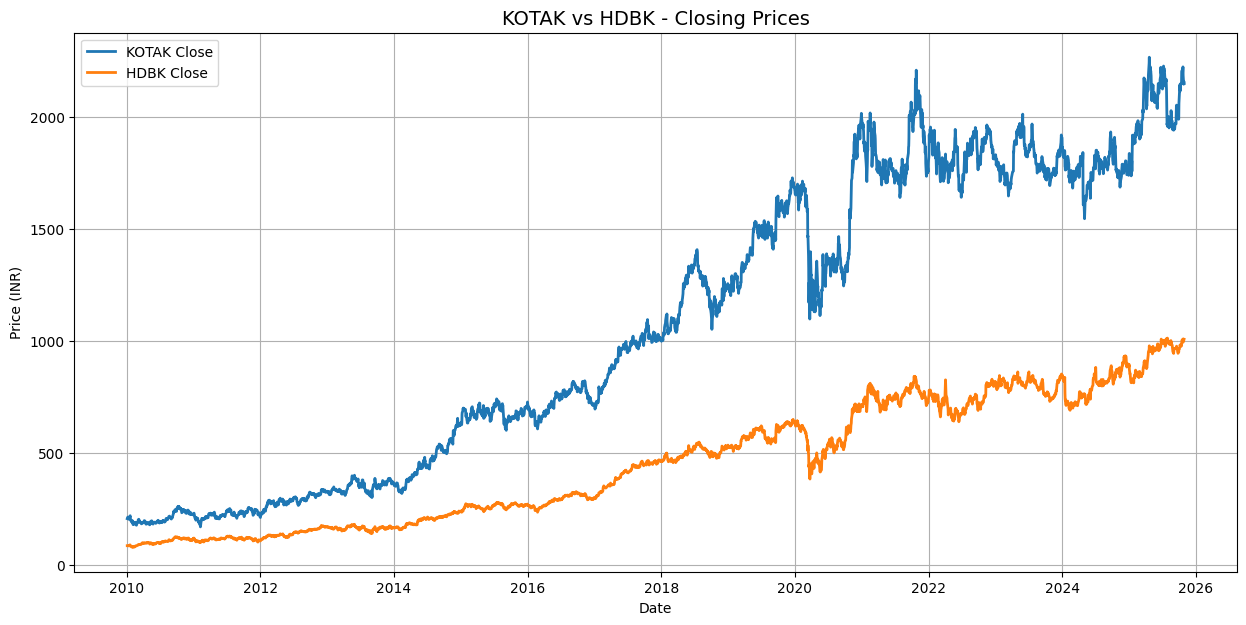

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_A = pd.read_csv('KOTAK Historical Data.csv')
df_B = pd.read_csv('HDBK Historical Data.csv')

# Standardize column names
df_A.columns = df_A.columns.str.strip().str.lower()
df_B.columns = df_B.columns.str.strip().str.lower()

# Rename for uniformity
df_A = df_A.rename(columns={'price': 'close', 'vol.': 'volume'})
df_B = df_B.rename(columns={'price': 'close', 'vol.': 'volume'})

# Parse dates safely (auto-detect format)
df_A['date'] = pd.to_datetime(df_A['date'], dayfirst=True, errors='coerce')
df_B['date'] = pd.to_datetime(df_B['date'], dayfirst=True, errors='coerce')

# Drop rows with invalid dates and set index
df_A = df_A.dropna(subset=['date']).set_index('date')
df_B = df_B.dropna(subset=['date']).set_index('date')

# Function to clean volume
def clean_volume(val):
    if isinstance(val, str):
        val = val.replace(',', '').strip()
        if val.endswith('K'):
            return float(val[:-1]) * 1e3
        elif val.endswith('M'):
            return float(val[:-1]) * 1e6
        elif val.endswith('B'):
            return float(val[:-1]) * 1e9
        else:
            try:
                return float(val)
            except ValueError:
                return np.nan
    return val

# Clean numeric columns
for col in ['open', 'high', 'low', 'close']:
    if col in df_A.columns:
        df_A[col] = pd.to_numeric(df_A[col].astype(str).str.replace(',', ''), errors='coerce')
    if col in df_B.columns:
        df_B[col] = pd.to_numeric(df_B[col].astype(str).str.replace(',', ''), errors='coerce')

# Clean volume columns
if 'volume' in df_A.columns:
    df_A['volume'] = df_A['volume'].apply(clean_volume)
if 'volume' in df_B.columns:
    df_B['volume'] = df_B['volume'].apply(clean_volume)

# Merge on aligned dates
pair_data = pd.DataFrame({
    'S1_close': df_A['close'],
    'S2_close': df_B['close'],
    'S1_open': df_A['open'],
    'S2_open': df_B['open'],
    'S1_high': df_A['high'],
    'S2_high': df_B['high'],
    'S1_low': df_A['low'],
    'S2_low': df_B['low'],
    'S1_volume': df_A['volume'],
    'S2_volume': df_B['volume']
}).dropna()

print(f"Pair dataset created for KOTAK ({len(df_A)}) and HDBK ({len(df_B)}) with {len(pair_data)} aligned records.")

# Plot closing prices
plt.figure(figsize=(15,7))
plt.plot(pair_data.index, pair_data['S1_close'], label='KOTAK Close', linewidth=2) # Changed label
plt.plot(pair_data.index, pair_data['S2_close'], label='HDBK Close', linewidth=2) # Changed label
plt.title("KOTAK vs HDBK - Closing Prices", fontsize=14) # Changed title
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Adding Technical Indicators for HDBK & KOTAK
# 1. Momentum Indicators
pair_data['S1_rsi'] = ta.momentum.rsi(pair_data['S1_close'], window=14)
pair_data['S2_rsi'] = ta.momentum.rsi(pair_data['S2_close'], window=14)
pair_data['S1_mfi'] = ta.volume.money_flow_index(
    high=pair_data['S1_high'], low=pair_data['S1_low'],
    close=pair_data['S1_close'], volume=pair_data['S1_volume'], window=14
)
pair_data['S2_mfi'] = ta.volume.money_flow_index(
    high=pair_data['S2_high'], low=pair_data['S2_low'],
    close=pair_data['S2_close'], volume=pair_data['S2_volume'], window=14
)

# 2. Volume Indicators
pair_data['S1_adi'] = ta.volume.acc_dist_index(
    high=pair_data['S1_high'], low=pair_data['S1_low'],
    close=pair_data['S1_close'], volume=pair_data['S1_volume']
)
pair_data['S2_adi'] = ta.volume.acc_dist_index(
    high=pair_data['S2_high'], low=pair_data['S2_low'],
    close=pair_data['S2_close'], volume=pair_data['S2_volume']
)
pair_data['S1_vpt'] = ta.volume.volume_price_trend(
    close=pair_data['S1_close'], volume=pair_data['S1_volume']
)
pair_data['S2_vpt'] = ta.volume.volume_price_trend(
    close=pair_data['S2_close'], volume=pair_data['S2_volume']
)

# 3. Volatility Indicators
pair_data['S1_atr'] = ta.volatility.average_true_range(
    high=pair_data['S1_high'], low=pair_data['S1_low'],
    close=pair_data['S1_close'], window=14
)
pair_data['S2_atr'] = ta.volatility.average_true_range(
    high=pair_data['S2_high'], low=pair_data['S2_low'],
    close=pair_data['S2_close'], window=14
)
pair_data['S1_bb_ma'] = ta.volatility.bollinger_mavg(pair_data['S1_close'], window=20)
pair_data['S2_bb_ma'] = ta.volatility.bollinger_mavg(pair_data['S2_close'], window=20)

# 4. Trend Indicators
pair_data['S1_adx'] = ta.trend.adx(
    high=pair_data['S1_high'], low=pair_data['S1_low'], close=pair_data['S1_close'], window=14
)
pair_data['S2_adx'] = ta.trend.adx(
    high=pair_data['S2_high'], low=pair_data['S2_low'], close=pair_data['S2_close'], window=14
)
pair_data['S1_ema'] = ta.trend.ema_indicator(pair_data['S1_close'], window=14)
pair_data['S2_ema'] = ta.trend.ema_indicator(pair_data['S2_close'], window=14)
pair_data['S1_macd'] = ta.trend.macd(pair_data['S1_close'], window_slow=30, window_fast=14)
pair_data['S2_macd'] = ta.trend.macd(pair_data['S2_close'], window_slow=30, window_fast=14)

# 5. Other Indicators
pair_data['S1_dlr'] = ta.others.daily_log_return(pair_data['S1_close'])
pair_data['S2_dlr'] = ta.others.daily_log_return(pair_data['S2_close'])

# Drop any initial NaN rows from rolling windows
pair_data = pair_data.dropna()

print(f"Added {len(pair_data.columns)} columns of indicators for HDBK & KOTAK.")
pair_data.head(10)

Added 30 columns of indicators for HDBK & KOTAK.


,S1_close,S2_close,S1_open,S2_open,S1_high,S2_high,S1_low,S2_low,S1_volume,S2_volume,...,S1_bb_ma,S2_bb_ma,S1_adx,S2_adx,S1_ema,S2_ema,S1_macd,S2_macd,S1_dlr,S2_dlr
date,,,,,,,,,,,,,,,,,,,,,
2010-02-15,181.93,80.31,201.00,79.47,201.00,80.60,181.30,78.75,873180.0,9600000.0,...,194.1225,81.3175,24.541563,15.434324,188.364013,80.080507,-6.329632,-1.492488,-1.033502,0.988558
2010-02-16,184.95,79.94,183.00,79.87,185.74,80.75,181.71,79.13,950930.0,14350000.0,...,192.7220,80.9185,23.211732,14.609670,187.908811,80.061772,-6.156212,-1.405867,1.646352,-0.461779
2010-02-17,189.56,82.41,185.45,80.52,190.96,82.66,185.25,80.37,2000000.0,24800000.0,...,191.4680,80.6120,22.678875,14.398695,188.128970,80.374869,-5.645407,-1.153568,2.462008,3.043044
2010-02-18,187.86,83.79,189.50,82.85,190.11,84.10,186.39,82.15,2230000.0,20010000.0,...,189.9205,80.4320,22.184079,14.886375,188.093107,80.830220,-5.299697,-0.844124,-0.900859,1.660688
2010-02-19,182.50,84.30,186.43,83.11,186.43,84.60,181.25,82.42,1020000.0,14690000.0,...,188.4910,80.3880,20.843390,15.558272,187.347360,81.292857,-5.342683,-0.550884,-2.894683,0.606820
2010-02-22,179.04,84.43,189.95,84.65,189.95,85.58,178.40,84.10,1130000.0,13280000.0,...,187.3215,80.4365,20.101244,16.592799,186.239712,81.711143,-5.569683,-0.299454,-1.914093,0.154092
2010-02-23,176.39,84.65,178.50,83.86,180.99,85.04,175.53,83.72,3470000.0,12950000.0,...,186.4145,80.5465,18.937615,17.267953,184.926417,82.102991,-5.888178,-0.077890,-1.491179,0.260232
2010-02-24,177.00,84.63,173.89,84.10,178.00,85.10,173.89,83.98,1430000.0,11210000.0,...,185.7015,80.8040,17.592462,17.922344,183.869561,82.439925,-6.053769,0.101037,0.345228,-0.023629
2010-02-25,182.49,84.16,202.53,84.65,202.53,84.80,178.47,83.70,5060000.0,11670000.0,...,185.0650,81.0475,18.948022,18.300050,183.685620,82.669269,-5.758141,0.212889,3.054564,-0.556906


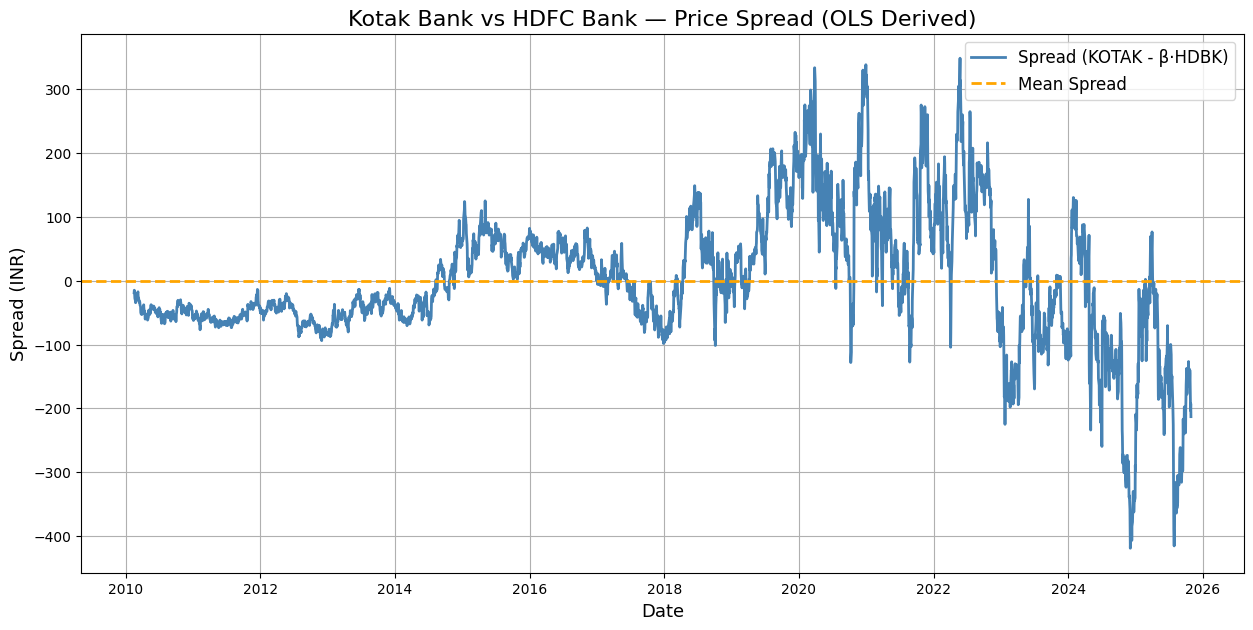

Hedge Ratio (β): 2.3318
Intercept (α): 13.4496


In [ ]:
#Compute and Plot OLS-Based Spread Between HDBK & KOTAK
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Run OLS regression: HDBK (dependent) vs KOTAK (independent)
# Note: S1 is KOTAK, S2 is HDBK. The code regresses S1(y) vs S2(X).
X = sm.add_constant(pair_data['S2_close'])  # add constant for intercept
y = pair_data['S1_close']
ols_model = sm.OLS(y, X).fit()

alpha = ols_model.params['const']
beta = ols_model.params['S2_close']

# Calculate spread
pair_data['Spread_Close'] = y - (beta * pair_data['S2_close'] + alpha)

# Plot the spread with mean line
plt.figure(figsize=(15,7))
plt.plot(pair_data.index, pair_data['Spread_Close'], label='Spread (KOTAK - β·HDBK)', linewidth=2, color='steelblue')
plt.axhline(pair_data['Spread_Close'].mean(), color='orange', linestyle='--', linewidth=2, label='Mean Spread')
plt.title('Kotak Bank vs HDFC Bank — Price Spread (OLS Derived)', fontsize=16)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Spread (INR)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Print hedge ratio
print(f"Hedge Ratio (β): {beta:.4f}")
print(f"Intercept (α): {alpha:.4f}")

OLS Hedge Ratios & Intercepts
Open: α = 13.3894, β = 2.3322
High: α = 14.2394, β = 2.3352
Low : α = 12.7146, β = 2.3277


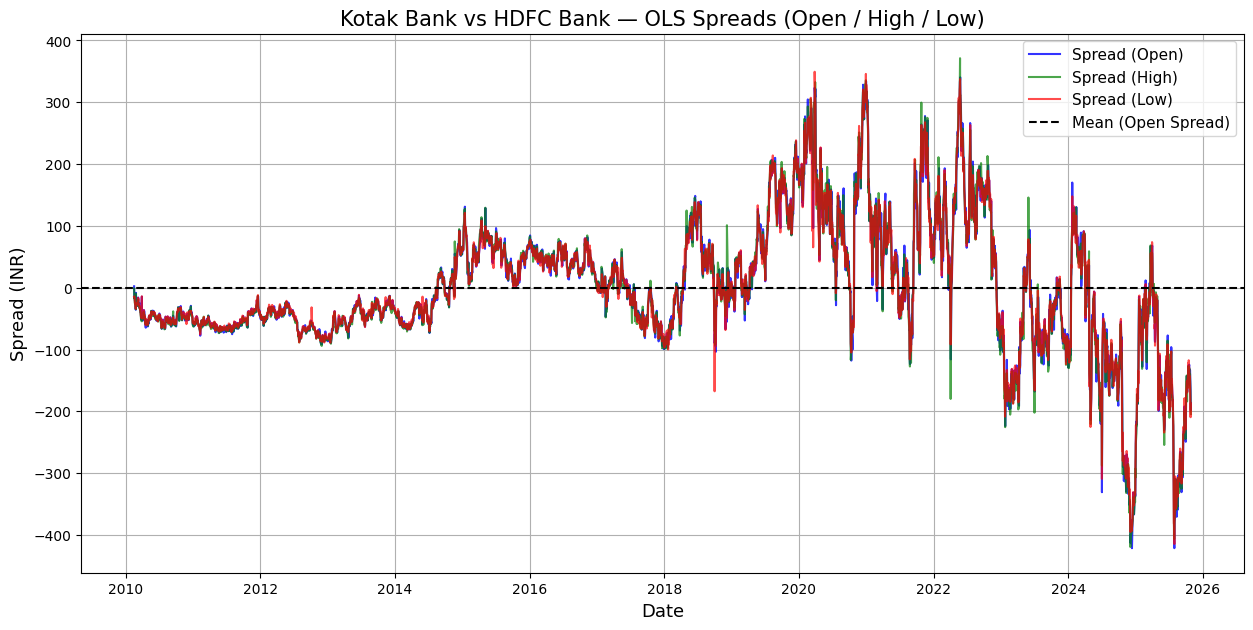

In [ ]:
#Compute OLS-Based Spreads for Open, High, and Low Prices
import statsmodels.api as sm
import matplotlib.pyplot as plt

#OPEN
X_open = sm.add_constant(pair_data['S2_open'])
y_open = pair_data['S1_open']
ols_open = sm.OLS(y_open, X_open).fit()
alpha_open = ols_open.params['const']
beta_open = ols_open.params['S2_open']
pair_data['Spread_Open'] = y_open - (beta_open * pair_data['S2_open'] + alpha_open)

#HIGH
X_high = sm.add_constant(pair_data['S2_high'])
y_high = pair_data['S1_high']
ols_high = sm.OLS(y_high, X_high).fit()
alpha_high = ols_high.params['const']
beta_high = ols_high.params['S2_high']
pair_data['Spread_High'] = y_high - (beta_high * pair_data['S2_high'] + alpha_high)

#LOW
X_low = sm.add_constant(pair_data['S2_low'])
y_low = pair_data['S1_low']
ols_low = sm.OLS(y_low, X_low).fit()
alpha_low = ols_low.params['const']
beta_low = ols_low.params['S2_low']
pair_data['Spread_Low'] = y_low - (beta_low * pair_data['S2_low'] + alpha_low)

#Print the regression stats
print("OLS Hedge Ratios & Intercepts")
print(f"Open: α = {alpha_open:.4f}, β = {beta_open:.4f}")
print(f"High: α = {alpha_high:.4f}, β = {beta_high:.4f}")
print(f"Low : α = {alpha_low:.4f}, β = {beta_low:.4f}")

#Plot the spreads
plt.figure(figsize=(15,7))
plt.plot(pair_data.index, pair_data['Spread_Open'], label='Spread (Open)', color='blue', alpha=0.8)
plt.plot(pair_data.index, pair_data['Spread_High'], label='Spread (High)', color='green', alpha=0.7)
plt.plot(pair_data.index, pair_data['Spread_Low'], label='Spread (Low)', color='red', alpha=0.7)
plt.axhline(pair_data['Spread_Open'].mean(), color='black', linestyle='--', linewidth=1.5, label='Mean (Open Spread)')
plt.title("Kotak Bank vs HDFC Bank — OLS Spreads (Open / High / Low)", fontsize=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Spread (INR)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

In [ ]:
#Prepare Normalized Dataset for LSTM
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

#Use MinMaxScaler to normalize Weighted Price to range from 0 to 1
cols = ['Spread_Close', 'Spread_Open', 'Spread_High', 'Spread_Low', 'S1_volume',
        'S2_volume', 'S1_rsi', 'S2_rsi', 'S1_mfi', 'S2_mfi', 'S1_adi', 'S2_adi',
        'S1_vpt', 'S2_vpt', 'S1_atr', 'S2_atr', 'S1_bb_ma', 'S2_bb_ma', 'S1_adx',
        'S2_adx', 'S1_ema', 'S2_ema', 'S1_macd', 'S2_macd', 'S1_dlr', 'S2_dlr']

lstm_pair_data = pd.DataFrame({
    'Spread_Close': pair_data['Spread_Close'][30:],
    'Spread_Open': pair_data['Spread_Open'][30:],
    'Spread_High': pair_data['Spread_High'][30:],
    'Spread_Low': pair_data['Spread_Low'][30:],
    'S1_volume': pair_data['S1_volume'][30:],
    'S2_volume': pair_data['S2_volume'][30:],
    'S1_rsi': pair_data['S1_rsi'][30:],
    'S2_rsi': pair_data['S2_rsi'][30:],
    'S1_mfi': pair_data['S1_mfi'][30:],
    'S2_mfi': pair_data['S2_mfi'][30:],
    'S1_adi': pair_data['S1_adi'][30:],
    'S2_adi': pair_data['S2_adi'][30:],
    'S1_vpt': pair_data['S1_vpt'][30:],
    'S2_vpt': pair_data['S2_vpt'][30:],
    'S1_atr': pair_data['S1_atr'][30:],
    'S2_atr': pair_data['S2_atr'][30:],
    'S1_bb_ma': pair_data['S1_bb_ma'][30:],
    'S2_bb_ma': pair_data['S2_bb_ma'][30:],
    'S1_adx': pair_data['S1_adx'][30:],
    'S2_adx': pair_data['S2_adx'][30:],
    'S1_ema': pair_data['S1_ema'][30:],
    'S2_ema': pair_data['S2_ema'][30:],
    'S1_macd': pair_data['S1_macd'][30:],
    'S2_macd': pair_data['S2_macd'][30:],
    'S1_dlr': pair_data['S1_dlr'][30:],
    'S2_dlr': pair_data['S2_dlr'][30:]
}, columns=cols)

In [ ]:
#Data Preparation (ML + DL)
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df_feat = lstm_pair_data.copy()

#Compute Z-Score Spread (stationary target)
df_feat['ZSpread'] = (
    (df_feat['Spread_Close'] - df_feat['Spread_Close'].rolling(30).mean())
    / df_feat['Spread_Close'].rolling(30).std()
)

#Add lagged features (short-term memory for ML models
lags = [1, 2, 3, 5, 10]
for lag in lags:
    df_feat[f'ZSpread_lag{lag}'] = df_feat['ZSpread'].shift(lag)

#Drop NaNs created by rolling & lagging
df_feat = df_feat.dropna().reset_index(drop=True)

#Define features and target
target_col = 'ZSpread'
features = [c for c in df_feat.columns if c != target_col]

#Normalize
x_scaler = MinMaxScaler()
X_scaled = x_scaler.fit_transform(df_feat[features])
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(df_feat[[target_col]]).flatten()

#Train/test split
split_idx = int(len(X_scaled) * 0.7)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

print("Unified dataset ready for ML + DL")
print(f"Features: {len(features)} | Target: {target_col}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Unified dataset ready for ML + DL
Features: 31 | Target: ZSpread
Train size: 2678, Test size: 1149


 Random Forest Results:
RMSE: 0.3712
R²:   0.9191


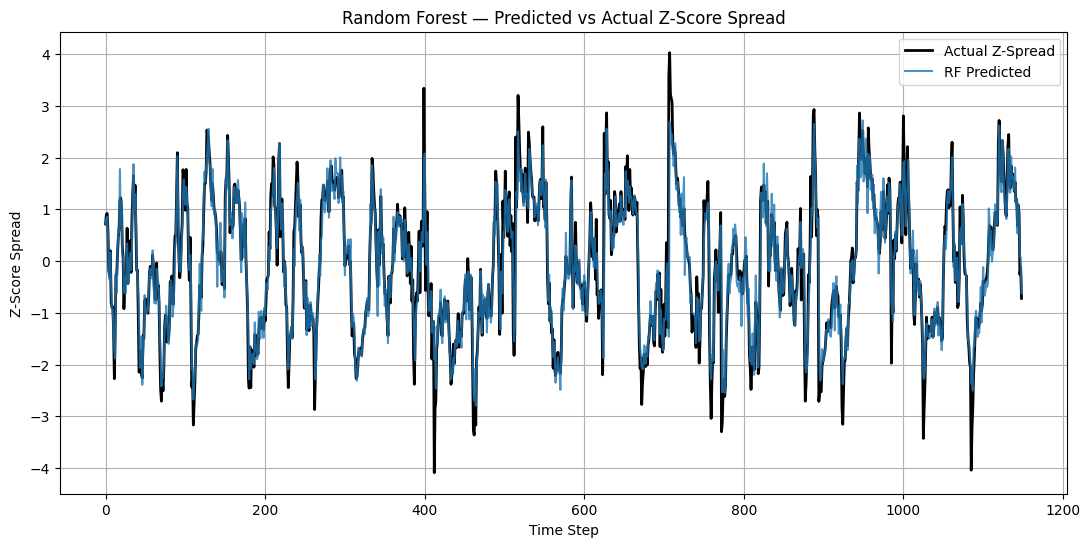

In [ ]:
#Random Forest (Unified Z-Score Domain)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred_scaled = rf.predict(X_test)
rf_pred = y_scaler.inverse_transform(rf_pred_scaled.reshape(-1,1)).flatten()
actual = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rf_rmse = np.sqrt(mean_squared_error(actual, rf_pred))
rf_r2 = r2_score(actual, rf_pred)

print(f" Random Forest Results:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²:   {rf_r2:.4f}")

ml_results = {}
ml_results["Random Forest"] = {"RMSE": rf_rmse, "R²": rf_r2}

plt.figure(figsize=(13,6))
plt.plot(actual, color='black', linewidth=2, label='Actual Z-Spread')
plt.plot(rf_pred, color='tab:blue', alpha=0.8, label='RF Predicted')
plt.title("Random Forest — Predicted vs Actual Z-Score Spread")
plt.xlabel("Time Step")
plt.ylabel("Z-Score Spread")
plt.legend()
plt.grid(True)
plt.show()

 SVR (RBF) Results:
RMSE: 0.4656
R²:   0.8727


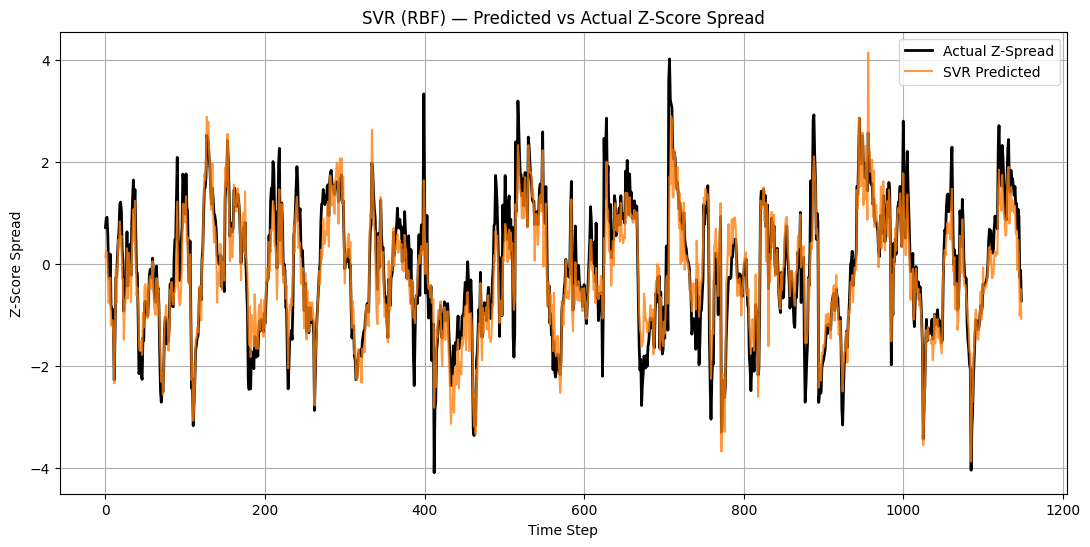

In [ ]:
#SVR (RBF Kernel, Unified Z-Score Domain)
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

svr = SVR(kernel='rbf', C=50, gamma=0.1)

svr.fit(X_train, y_train)

svr_pred_scaled = svr.predict(X_test)
svr_pred = y_scaler.inverse_transform(svr_pred_scaled.reshape(-1,1)).flatten()
actual = y_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

svr_rmse = np.sqrt(mean_squared_error(actual, svr_pred))
svr_r2 = r2_score(actual, svr_pred)

print(f" SVR (RBF) Results:")
print(f"RMSE: {svr_rmse:.4f}")
print(f"R²:   {svr_r2:.4f}")

ml_results["SVR (RBF)"] = {"RMSE": svr_rmse, "R²": svr_r2}

plt.figure(figsize=(13,6))
plt.plot(actual, color='black', linewidth=2, label='Actual Z-Spread')
plt.plot(svr_pred, color='tab:orange', alpha=0.8, label='SVR Predicted')
plt.title("SVR (RBF) — Predicted vs Actual Z-Score Spread")
plt.xlabel("Time Step")
plt.ylabel("Z-Score Spread")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
#Define Sequence Creation Function

def create_sequences(X_data, y_data, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X_data) - time_steps):
        # Get a window of features
        v = X_data[i:(i + time_steps)]
        Xs.append(v)
        # Get the target value after the window
        ys.append(y_data[i + time_steps])
    return np.array(Xs), np.array(ys)

#Create 3D Sequence Data
lookback = 60
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)

#Split the 3D sequence data
split_idx = int(len(X_seq) * 0.7)
trainX, testX = X_seq[:split_idx], X_seq[split_idx:]
trainY, testY = y_seq[:split_idx], y_seq[split_idx:]

print(f" Sequence data created with lookback={lookback}")
print(f"Shapes → trainX: {trainX.shape}, testX: {testX.shape}")
print(f"Shapes → trainY: {trainY.shape}, testY: {testY.shape}")

 Sequence data created with lookback=60
Shapes → trainX: (2636, 60, 31), testX: (1131, 60, 31)
Shapes → trainY: (2636,), testY: (1131,)


Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0428 - val_loss: 0.0105 - learning_rate: 5.0000e-04
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0112 - val_loss: 0.0089 - learning_rate: 5.0000e-04
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0089 - val_loss: 0.0084 - learning_rate: 5.0000e-04
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0085 - val_loss: 0.0074 - learning_rate: 5.0000e-04
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0083 - val_loss: 0.0071 - learning_rate: 5.0000e-04
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0072 - val_loss: 0.0069 - learning_rate: 5.0000e-04
Epoch 7/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0072 - val_loss: 0.0065 - learning_rate: 5.0000e-04
Epoch 8/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0069 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 9/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0061 - val_loss: 0.0060 - learning_

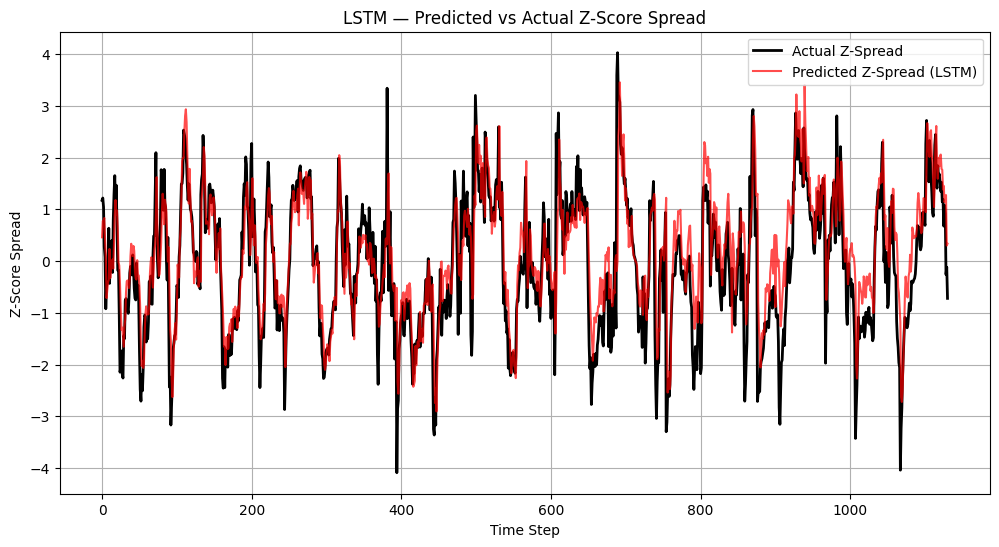

In [ ]:
#LSTM (Unified Z-Score Domain)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

model_lstm = Sequential([
    LSTM(64, input_shape=(lookback, X_seq.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history_lstm = model_lstm.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=60,
    batch_size=32,
    callbacks=[es, lr_sched],
    verbose=1
)

#Predictions
pred_scaled = model_lstm.predict(testX).flatten()
pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual = y_scaler.inverse_transform(testY.reshape(-1, 1)).flatten()

#Store for backtesting
lstm_preds = pred

#Evaluation
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(" LSTM (Z-Score Target) Results:")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

#Plot
plt.figure(figsize=(12,6))
plt.plot(actual, color='black', linewidth=2, label='Actual Z-Spread')
plt.plot(pred, color='red', alpha=0.7, label='Predicted Z-Spread (LSTM)')
plt.title("LSTM — Predicted vs Actual Z-Score Spread")
plt.xlabel("Time Step")
plt.ylabel("Z-Score Spread")
plt.legend()
plt.grid(True)
plt.show()


Training CNN-LSTM on unified Z-Score domain...
Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - loss: 0.0806 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - loss: 0.0194 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - loss: 0.0175 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - loss: 0.0153 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - loss: 0.0144 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 6/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - loss: 0.0150 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 7/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - loss: 0.0140 - val_loss: 0.0236 - learning_rate: 0.0010
Epoch 8/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - loss: 0.0126 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 9/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - loss: 

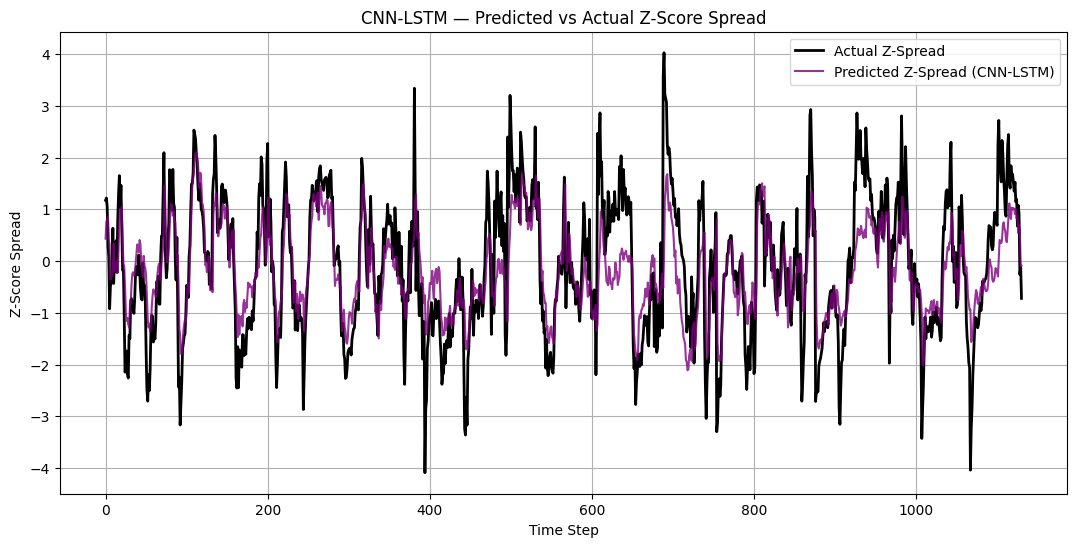

In [ ]:
#CNN-LSTM (Unified Z-Score Domain)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

#Model
model_cnn_lstm = Sequential([
    Conv1D(256, kernel_size=5, activ₹ation='relu', padding='same', input_shape=(lookback, X_seq.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),
    LSTM(128, return_sequences=True),
    Dropout(0.1),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(1)
])

model_cnn_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)

print("\nTraining CNN-LSTM on unified Z-Score domain...")
history_cnn_lstm = model_cnn_lstm.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=150,
    batch_size=64,
    callbacks=[es, lr_sched],
    verbose=1
)
#Prediction & Evaluation
pred_scaled = model_cnn_lstm.predict(testX).flatten()
pred = y_scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
actual = y_scaler.inverse_transform(testY.reshape(-1,1)).flatten()

cnn_preds = pred  # for backtesting

rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print(f"\n CNN-LSTM Results:")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

#Plot
plt.figure(figsize=(13,6))
plt.plot(actual, color='black', linewidth=2, label='Actual Z-Spread')
plt.plot(pred, color='purple', alpha=0.8, label='Predicted Z-Spread (CNN-LSTM)')
plt.title("CNN-LSTM — Predicted vs Actual Z-Score Spread")
plt.xlabel("Time Step")
plt.ylabel("Z-Score Spread")
plt.legend()
plt.grid(True)
plt.show()

=== 📈 ALIGNED MODEL PERFORMANCE COMPARISON ===


,RMSE,R²
Random Forest,0.3732,0.9190
SVR (RBF),0.4663,0.8735
LSTM,0.7780,0.6477
CNN-LSTM,0.8463,0.5832


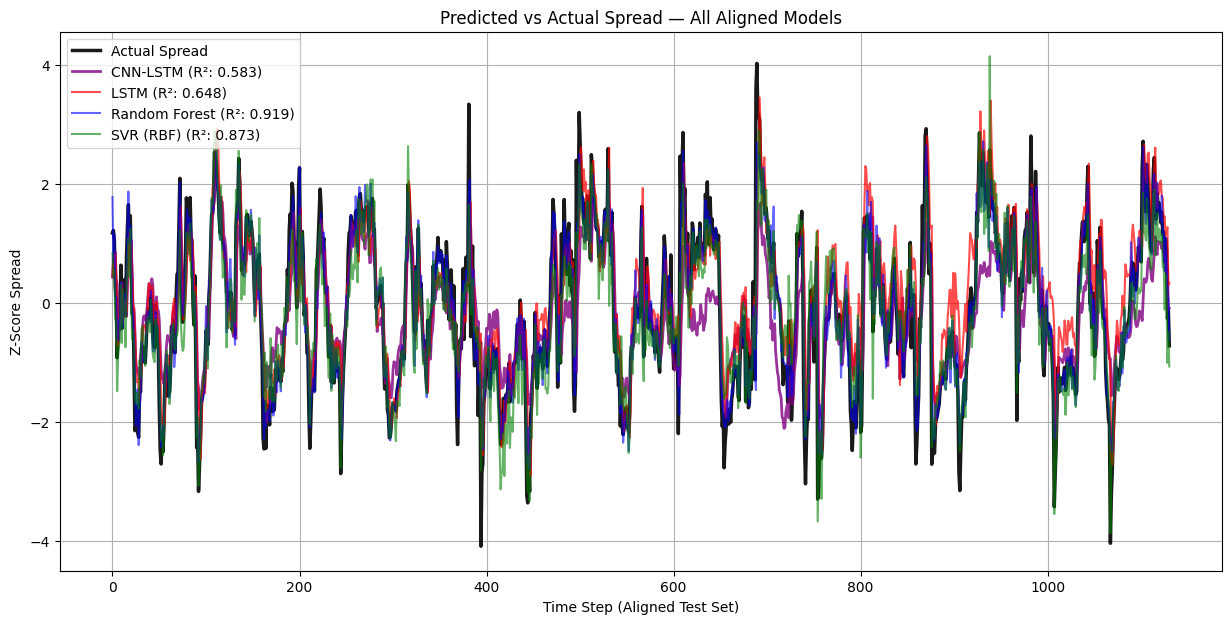

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

#Align Predictions & Re-Calculate Metrics
actual_test_aligned = actual
test_len = len(actual_test_aligned)

rf_preds_aligned = rf_pred[-test_len:]
svr_preds_aligned = svr_pred[-test_len:]

lstm_preds_aligned = lstm_preds
cnn_preds_aligned = cnn_preds

ml_results = {
    "Random Forest": {
        "RMSE": np.sqrt(mean_squared_error(actual_test_aligned, rf_preds_aligned)),
        "R²": r2_score(actual_test_aligned, rf_preds_aligned)
    },
    "SVR (RBF)": {
        "RMSE": np.sqrt(mean_squared_error(actual_test_aligned, svr_preds_aligned)),
        "R²": r2_score(actual_test_aligned, svr_preds_aligned)
    },
    "LSTM": {
        "RMSE": np.sqrt(mean_squared_error(actual_test_aligned, lstm_preds_aligned)),
        "R²": r2_score(actual_test_aligned, lstm_preds_aligned)
    },
    "CNN-LSTM": {
        "RMSE": np.sqrt(mean_squared_error(actual_test_aligned, cnn_preds_aligned)),
        "R²": r2_score(actual_test_aligned, cnn_preds_aligned)
    }
}

results_df = pd.DataFrame(ml_results).T
results_df = results_df.round(4)

print("ALIGNED MODEL PERFORMANCE COMPARISON")
display(results_df)

#Combined Prediction Plot
plt.figure(figsize=(15, 7))
plt.plot(actual_test_aligned, label='Actual Spread', color='black', linewidth=2.5, alpha=0.9)
plt.plot(cnn_preds_aligned, label=f"CNN-LSTM (R²: {ml_results['CNN-LSTM']['R²']:.3f})", color='purple', linewidth=2, alpha=0.8)
plt.plot(lstm_preds_aligned, label=f"LSTM (R²: {ml_results['LSTM']['R²']:.3f})", color='red', alpha=0.7)
plt.plot(rf_preds_aligned, label=f"Random Forest (R²: {ml_results['Random Forest']['R²']:.3f})", color='blue', alpha=0.6)
plt.plot(svr_preds_aligned, label=f"SVR (RBF) (R²: {ml_results['SVR (RBF)']['R²']:.3f})", color='green', alpha=0.6)

plt.title("Predicted vs Actual Spread — All Aligned Models")
plt.xlabel("Time Step (Aligned Test Set)")
plt.ylabel("Z-Score Spread")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Backtesting Helper Functions

#Helper: generate trading signals based on z-score
def generate_signals(spread_pred, entry_z=1.0, exit_z=0.2):

    # Calculate z-score *of the predictions*
    z = (spread_pred - np.mean(spread_pred)) / np.std(spread_pred)
    signals = np.zeros_like(z)

    # 1 = Go Long Spread (buy S1, sell S2):Expects spread to rise
    signals[z < -entry_z] = 1
    # -1 = Go Short Spread (sell S1, buy S2):Expects spread to fall
    signals[z > entry_z] = -1

    # Hold position until exit signal
    for i in range(1, len(z)):
        if abs(z[i]) < exit_z:
            signals[i] = 0  # Exit position
        elif signals[i] == 0:
            signals[i] = signals[i-1] # Maintain previous position
    return signals, z

#Helper: compute returns given signals and actual spread changes
def compute_returns(spread_actual, signals):

    # Spread change = Δspread (t+1 - t)
    spread_diff = np.diff(spread_actual)

    # Align signals (exclude last value)
    signals = signals[:-1]

    returns = signals * spread_diff

    cum_returns = np.cumsum(returns)
    return returns, cum_returns

FINAL COMPARISON (PERFORMANCE + PROFITABILITY)


,RMSE,R²,Sharpe,Total Return
SVR (RBF),0.4663,0.8735,0.215,125.57
Random Forest,0.3732,0.9190,0.204,123.22
CNN-LSTM,0.8463,0.5832,0.202,117.39
LSTM,0.7780,0.6477,0.201,112.67


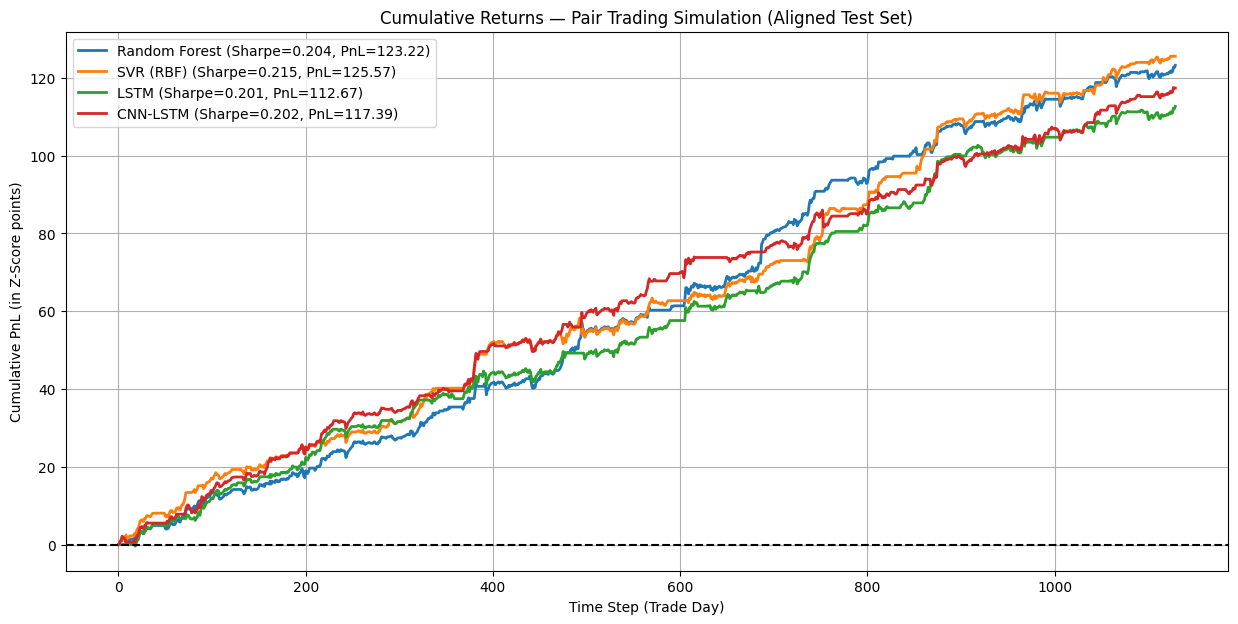

In [ ]:
#Backtesting & Profit Simulation

# Use the aligned actual spread values as our ground truth for PnL
spread_actual_test = actual_test_aligned

#Collect backtest results for each model
backtest_results = {}

# Loop through our aligned predictions
for model_name, preds in [
    ('Random Forest', rf_preds_aligned),
    ('SVR (RBF)', svr_preds_aligned),
    ('LSTM', lstm_preds_aligned),
    ('CNN-LSTM', cnn_preds_aligned)
]:
    # 1. Generate signals from this model's predictions
    signals, z = generate_signals(preds, entry_z=0.8, exit_z=0.1)

    # 2. Compute returns based on signals and *actual* spread changes
    returns, cum_returns = compute_returns(spread_actual_test, signals)

    backtest_results[model_name] = {
        'signals': signals,
        'returns': returns,
        'cum_returns': cum_returns
    }

    # 3. Compute Sharpe Ratio (Daily)
    sharpe = (np.mean(returns) / (np.std(returns) + 1e-9))

    # 4. Add results to our main summary dictionary
    ml_results[model_name]['Sharpe'] = round(sharpe, 3)
    ml_results[model_name]['Total Return'] = round(backtest_results[model_name]['cum_returns'][-1], 2)

#Summary DataFrame
results_df = pd.DataFrame(ml_results).T.round(4)
print("FINAL COMPARISON (PERFORMANCE + PROFITABILITY)")
display(results_df[['RMSE', 'R²', 'Sharpe', 'Total Return']].sort_values(by='Sharpe', ascending=False))

#Plot Cumulative Returns
plt.figure(figsize=(15,7))
for model_name, data in backtest_results.items():
    plt.plot(data['cum_returns'],
             label=f"{model_name} (Sharpe={ml_results[model_name]['Sharpe']}, PnL={ml_results[model_name]['Total Return']})",
             linewidth=2)

plt.title("Cumulative Returns — Pair Trading Simulation (Aligned Test Set)")
plt.xlabel("Time Step (Trade Day)")
plt.ylabel("Cumulative PnL (in Z-Score points)")
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linestyle='--')
plt.show()